In [15]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 잘 불러와지는지 테스트
spy = yf.download("SPY", start="2020-01-01", end="2024-12-31")
print(spy.tail())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2024-12-23  586.186646  586.787909  579.257137  582.440993  57635800
2024-12-24  592.702087  592.741554  586.955433  587.537023  33160100
2024-12-26  592.741577  593.865231  589.528182  590.927860  41219100
2024-12-27  586.502014  589.232425  582.312785  588.995807  64969300
2024-12-30  579.809082  583.278769  576.053563  579.483844  56578800


In [17]:
# 사용할 ETF 목록
tickers = ["SPY", "QQQ", "BND", "SCHD"]

# 2015년부터 2024년까지 데이터 다운로드
data = yf.download(tickers, start="2015-01-01") #end 없으면 오늘까지

# 종가(Close)만 추출
prices = data["Close"]
print(prices.head())
print(f"\n데이터 크기: {prices.shape}")  # (행 수, 열 수)

[*********************100%***********************]  4 of 4 completed

Ticker            BND        QQQ      SCHD         SPY
Date                                                  
2015-01-02  59.603508  94.665092  9.151194  170.124985
2015-01-05  59.776611  93.276474  9.022466  167.052673
2015-01-06  59.949677  92.025749  8.967296  165.479126
2015-01-07  59.985733  93.212090  9.073037  167.541199
2015-01-08  59.892006  94.996147  9.240842  170.514191

데이터 크기: (2849, 4)


In [18]:
# 일별 수익률 계산
returns = prices.pct_change().dropna()

# 각 ETF 연평균 수익률 & 변동성 확인
annual_return = returns.mean() * 252  # 1년 거래일 약 252일
annual_vol = returns.std() * (252 ** 0.5)

summary = pd.DataFrame({
    '연평균 수익률': (annual_return * 100).round(2).astype(str) + '%',
    '연간 변동성': (annual_vol * 100).round(2).astype(str) + '%'
})

print(summary)

       연평균 수익률  연간 변동성
Ticker                
BND      1.98%   5.33%
QQQ     19.77%  21.88%
SCHD     12.4%  16.47%
SPY     14.35%  17.69%


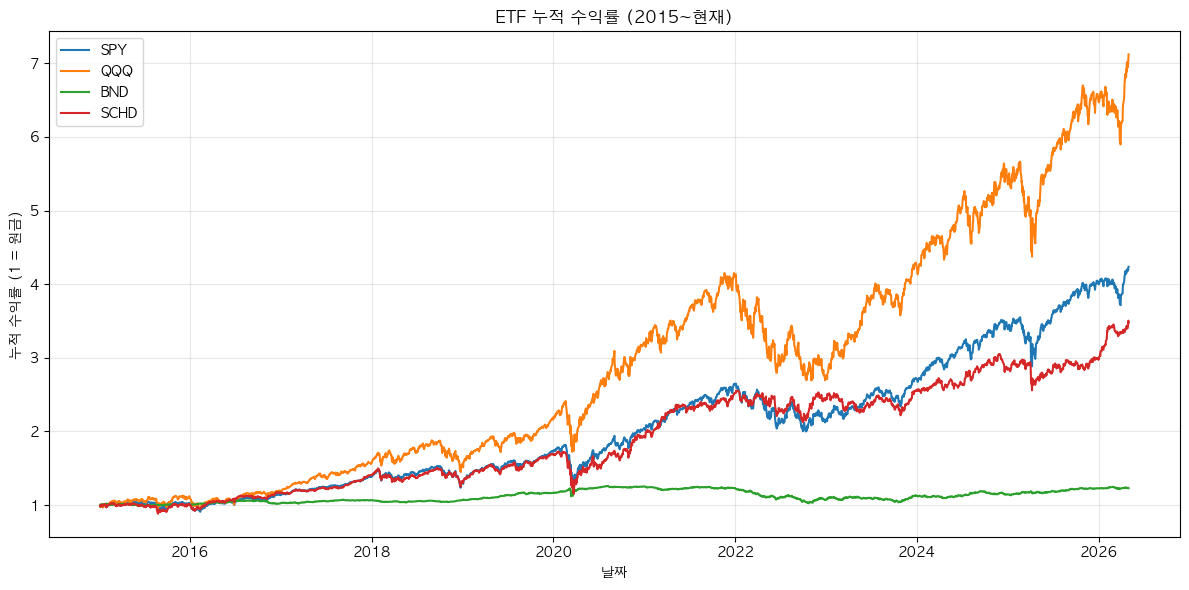

In [19]:
# 누적 수익률 시각화
cumulative = (1 + returns).cumprod()

plt.figure(figsize=(12, 6))
for ticker in tickers:
    plt.plot(cumulative.index, cumulative[ticker], label=ticker)

plt.title('ETF 누적 수익률 (2015~현재)')
plt.xlabel('날짜')
plt.ylabel('누적 수익률 (1 = 원금)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# 월 적립 백테스팅 함수
def backtest_monthly(prices, weights, monthly_amount, start_date="2015-01-01"):
    # 월별 마지막 거래일만 추출
    monthly_prices = prices.resample('ME').last()
    monthly_prices = monthly_prices[monthly_prices.index >= start_date]
    
    portfolio_value = []
    total_invested = []
    shares = {ticker: 0 for ticker in prices.columns}
    invested = 0

    for date, row in monthly_prices.iterrows():
        # 매월 투자금 배분
        for ticker, weight in weights.items():
            alloc = monthly_amount * weight
            price = row[ticker]
            if price > 0:
                shares[ticker] += alloc / price
        
        invested += monthly_amount
        
        # 현재 포트폴리오 가치
        value = sum(shares[t] * row[t] for t in shares)
        portfolio_value.append(value)
        total_invested.append(invested)
    
    result = pd.DataFrame({
        '포트폴리오 가치': portfolio_value,
        '투자 원금': total_invested
    }, index=monthly_prices.index)
    
    return result

# 균형형 포트폴리오 설정
weights = {'SPY': 0.45, 'QQQ': 0.25, 'BND': 0.15, 'SCHD': 0.15}
monthly_amount = 300000  # 월 30만원

result = backtest_monthly(prices, weights, monthly_amount)
print(result.tail())

                포트폴리오 가치     투자 원금
Date                              
2026-01-31  9.306076e+07  39900000
2026-02-28  9.312384e+07  40200000
2026-03-31  8.936526e+07  40500000
2026-04-30  9.915344e+07  40800000
2026-05-31  9.983193e+07  41100000


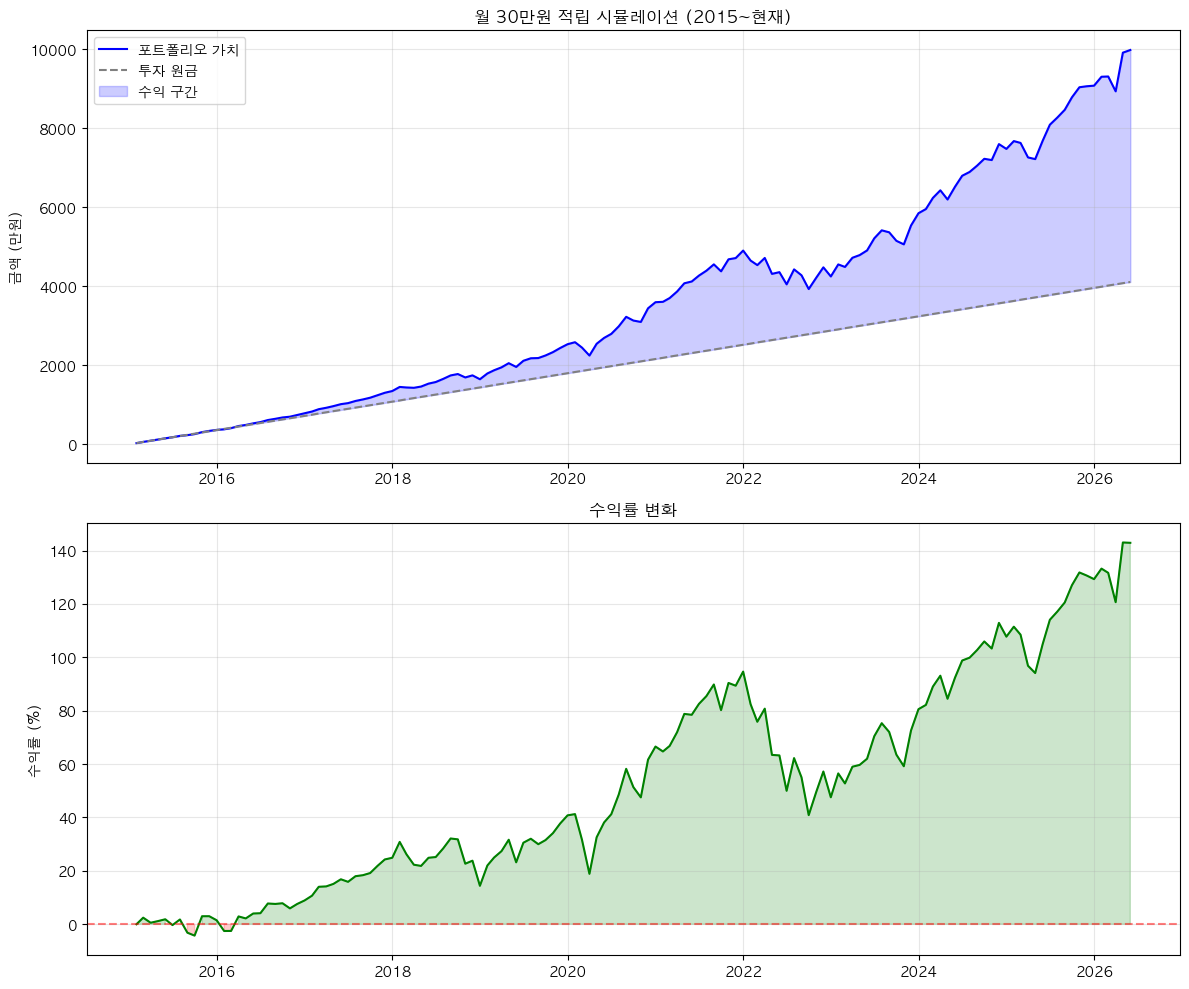

In [21]:
# 시각화
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# 상단: 포트폴리오 가치 vs 원금
ax1.plot(result.index, result['포트폴리오 가치'] / 10000, label='포트폴리오 가치', color='blue')
ax1.plot(result.index, result['투자 원금'] / 10000, label='투자 원금', color='gray', linestyle='--')
ax1.fill_between(result.index,
                 result['투자 원금'] / 10000,
                 result['포트폴리오 가치'] / 10000,
                 alpha=0.2, color='blue', label='수익 구간')
ax1.set_title('월 30만원 적립 시뮬레이션 (2015~현재)')
ax1.set_ylabel('금액 (만원)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 하단: 수익률
profit_rate = (result['포트폴리오 가치'] / result['투자 원금'] - 1) * 100
ax2.plot(result.index, profit_rate, color='green')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax2.fill_between(result.index, 0, profit_rate,
                 where=profit_rate >= 0, color='green', alpha=0.2)
ax2.fill_between(result.index, 0, profit_rate,
                 where=profit_rate < 0, color='red', alpha=0.2)
ax2.set_title('수익률 변화')
ax2.set_ylabel('수익률 (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# 세금 계산 함수
def calculate_tax(result, monthly_amount):
    final_value = result['포트폴리오 가치'].iloc[-1]
    total_invested = result['투자 원금'].iloc[-1]
    profit = final_value - total_invested
    
    # 양도소득세 계산
    deduction = 2_500_000  # 연간 250만원 공제
    taxable_profit = max(0, profit - deduction)
    capital_gains_tax = taxable_profit * 0.22
    
    # 세후 자산
    after_tax = final_value - capital_gains_tax
    
    print("=" * 40)
    print(f"총 투자 원금:     {total_invested/10000:,.0f}만원")
    print(f"세전 최종 자산:   {final_value/10000:,.0f}만원")
    print(f"총 수익:          {profit/10000:,.0f}만원")
    print(f"양도소득세 (22%): {capital_gains_tax/10000:,.0f}만원")
    print(f"세후 최종 자산:   {after_tax/10000:,.0f}만원")
    print(f"실질 수익률:      {(after_tax/total_invested - 1)*100:.1f}%")
    print("=" * 40)
    
    return after_tax

after_tax = calculate_tax(result, monthly_amount)

총 투자 원금:     4,110만원
세전 최종 자산:   9,983만원
총 수익:          5,873만원
양도소득세 (22%): 1,237만원
세후 최종 자산:   8,746만원
실질 수익률:      112.8%


In [23]:
def calculate_isa_tax(result):
    final_value = result['포트폴리오 가치'].iloc[-1]
    total_invested = result['투자 원금'].iloc[-1]
    profit = final_value - total_invested
    
    # ISA 계좌: 200만원 비과세, 초과분 9.9% 분리과세
    isa_deduction = 2_000_000
    taxable_profit = max(0, profit - isa_deduction)
    isa_tax = taxable_profit * 0.099
    isa_after_tax = final_value - isa_tax
    
    # 일반 계좌: 250만원 공제 후 22%
    general_deduction = 2_500_000
    general_taxable = max(0, profit - general_deduction)
    general_tax = general_taxable * 0.22
    general_after_tax = final_value - general_tax
    
    print("=" * 45)
    print(f"{'':12} {'일반 계좌':>12} {'ISA 계좌':>12}")
    print("-" * 45)
    print(f"{'세금':12} {general_tax/10000:>10.0f}만원 {isa_tax/10000:>10.0f}만원")
    print(f"{'세후 자산':12} {general_after_tax/10000:>10.0f}만원 {isa_after_tax/10000:>10.0f}만원")
    print(f"{'절세 효과':12} {'':>12} {(general_tax-isa_tax)/10000:>10.0f}만원 아낌")
    print("=" * 45)

calculate_isa_tax(result)

                    일반 계좌       ISA 계좌
---------------------------------------------
세금                 1237만원        562만원
세후 자산              8746만원       9422만원
절세 효과                            675만원 아낌


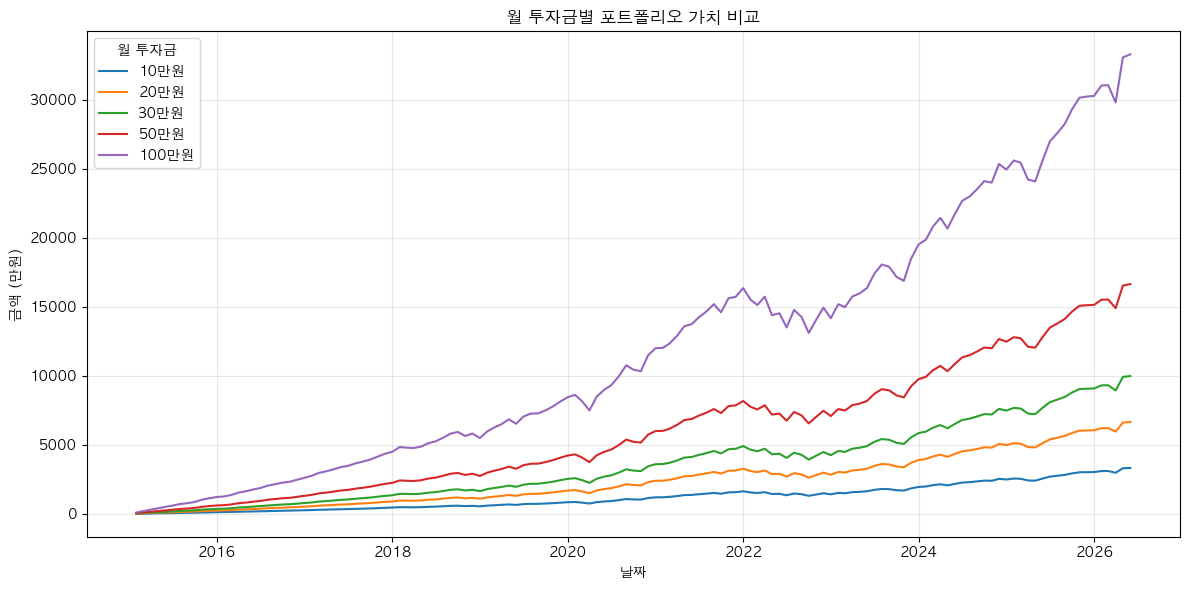

In [24]:
# 월 투자금별 비교 (10만/20만/30만/50만/100만원)
amounts = [100000, 200000, 300000, 500000, 1000000]
labels = ['10만원', '20만원', '30만원', '50만원', '100만원']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

plt.figure(figsize=(12, 6))

for amount, label, color in zip(amounts, labels, colors):
    r = backtest_monthly(prices, weights, amount)
    plt.plot(r.index, r['포트폴리오 가치'] / 10000, label=label, color=color)

plt.title('월 투자금별 포트폴리오 가치 비교')
plt.xlabel('날짜')
plt.ylabel('금액 (만원)')
plt.legend(title='월 투자금')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

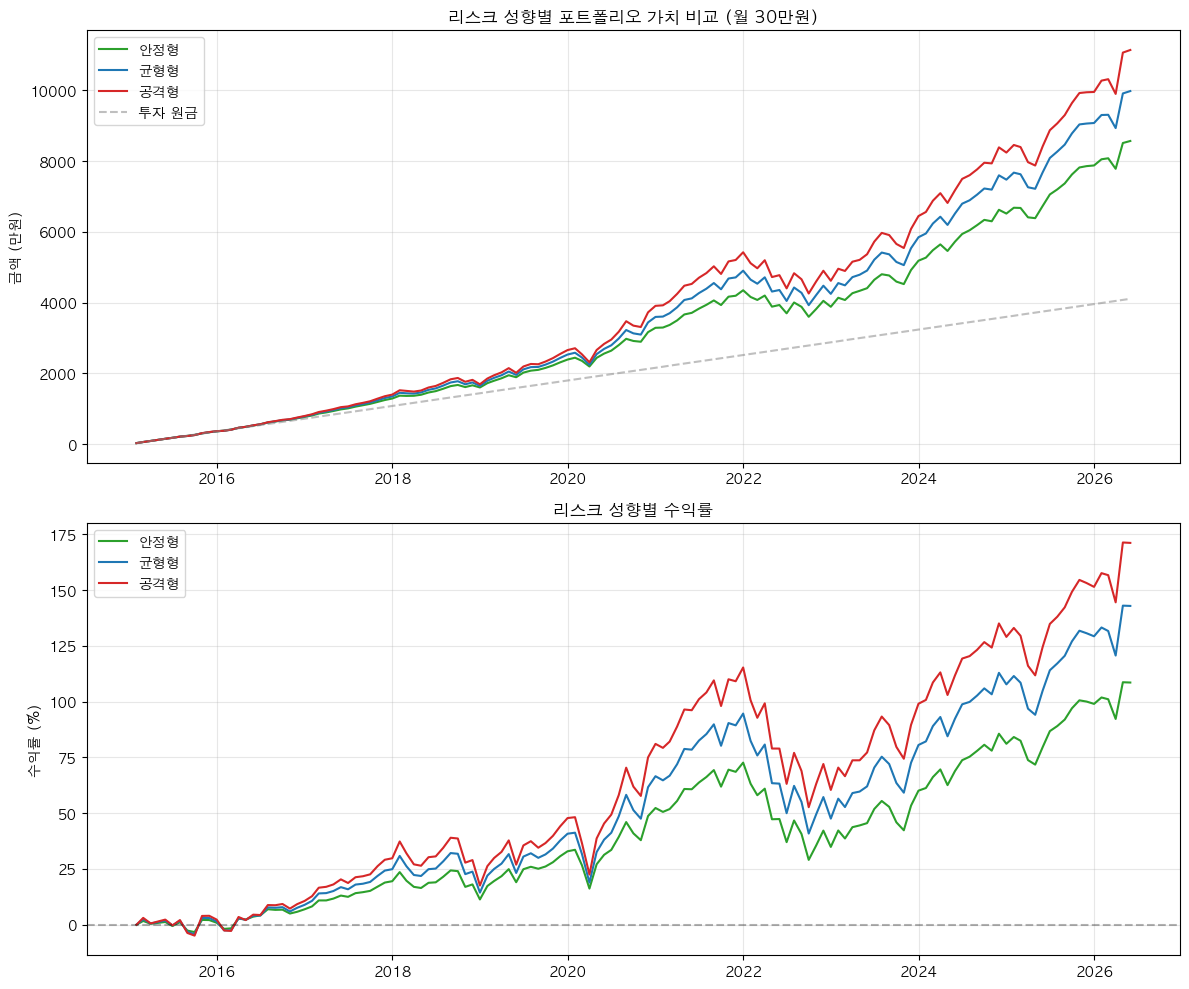

In [25]:
# 리스크 성향별 포트폴리오 정의
portfolios = {
    '안정형': {'SPY': 0.40, 'QQQ': 0.15, 'BND': 0.35, 'SCHD': 0.10},
    '균형형': {'SPY': 0.45, 'QQQ': 0.25, 'BND': 0.15, 'SCHD': 0.15},
    '공격형': {'SPY': 0.30, 'QQQ': 0.40, 'BND': 0.00, 'SCHD': 0.30},
}
colors = {'안정형': '#2ca02c', '균형형': '#1f77b4', '공격형': '#d62728'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

monthly_amount = 300000

for name, w in portfolios.items():
    r = backtest_monthly(prices, w, monthly_amount)
    profit_rate = (r['포트폴리오 가치'] / r['투자 원금'] - 1) * 100
    ax1.plot(r.index, r['포트폴리오 가치'] / 10000, label=name, color=colors[name])
    ax2.plot(r.index, profit_rate, label=name, color=colors[name])

# 원금선
r0 = backtest_monthly(prices, portfolios['균형형'], monthly_amount)
ax1.plot(r0.index, r0['투자 원금'] / 10000, '--', color='gray', label='투자 원금', alpha=0.5)

ax1.set_title('리스크 성향별 포트폴리오 가치 비교 (월 30만원)')
ax1.set_ylabel('금액 (만원)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_title('리스크 성향별 수익률')
ax2.set_ylabel('수익률 (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
from groq import Groq

# API 키 설정
client = Groq(api_key="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")

# 지금까지 계산한 결과 정리
monthly_amount = 300000
r = backtest_monthly(prices, portfolios['균형형'], monthly_amount)
final_value = r['포트폴리오 가치'].iloc[-1]
total_invested = r['투자 원금'].iloc[-1]
profit = final_value - total_invested
general_tax = max(0, profit - 2_500_000) * 0.22
isa_tax = max(0, profit - 2_000_000) * 0.099

prompt = f"""
당신은 한국인 투자자를 위한 친절한 금융 어드바이저입니다.
아래 투자 시뮬레이션 결과를 바탕으로 한국어로 맞춤형 투자 리포트를 작성해주세요.

[투자 조건]
- 월 투자금: {monthly_amount//10000}만원
- 포트폴리오: SPY 45%, QQQ 25%, BND 15%, SCHD 15% (균형형)
- 투자 기간: 2015년~현재 (약 11년)

[시뮬레이션 결과]
- 총 투자 원금: {total_invested/10000:,.0f}만원
- 세전 최종 자산: {final_value/10000:,.0f}만원
- 총 수익: {profit/10000:,.0f}만원
- 일반 계좌 세금(22%): {general_tax/10000:,.0f}만원
- ISA 계좌 세금(9.9%): {isa_tax/10000:,.0f}만원
- ISA 절세 효과: {(general_tax-isa_tax)/10000:,.0f}만원

다음 내용을 포함해서 300자 내외로 작성해주세요:
1. 이 포트폴리오의 성과 평가
2. 주의해야 할 리스크
3. ISA 계좌 활용 절세 팁
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

친애하는 투자자님, 

저와 함께 투자하였던 SPY, QQQ, BND, SCHD로 구성된 균형형 포트폴리오의 성과는 뛰어난 편입니다. 총 투자 원금 4,110만원 중 5,873만원의 수익을 거두어, 세전 최종 자산은 9,983만원으로 나타났습니다. 

다만, 경기 변동성 및 시장 위험성 등으로 인한 잠재적인 리스크를 주의해야 합니다. 

ISA 계좌를 활용하면 약 675만원의 절세 효과를 누릴 수 있습니다. ISA 계좌를 적극 활용하시길 권장합니다.


In [27]:
prompt = f"""
당신은 한국인 투자자를 위한 전문 금융 어드바이저입니다.
아래 투자 시뮬레이션 결과를 바탕으로 상세한 한국어 투자 리포트를 작성해주세요.

[투자 조건]
- 월 투자금: {monthly_amount//10000}만원
- 포트폴리오: SPY 45%, QQQ 25%, BND 15%, SCHD 15% (균형형)
- 투자 기간: 2015년~현재 (약 11년)

[시뮬레이션 결과]
- 총 투자 원금: {total_invested/10000:,.0f}만원
- 세전 최종 자산: {final_value/10000:,.0f}만원
- 총 수익: {profit/10000:,.0f}만원
- 일반 계좌 세금(22%): {general_tax/10000:,.0f}만원
- ISA 계좌 세금(9.9%): {isa_tax/10000:,.0f}만원
- ISA 절세 효과: {(general_tax-isa_tax)/10000:,.0f}만원

아래 형식으로 작성해주세요:

📊 포트폴리오 성과 분석
(수익률, 복리 효과, 각 ETF 역할 설명)

⚠️ 주요 리스크
(환율 리스크, 시장 변동성, 미중 관세 이슈 등 구체적으로)

💡 절세 전략
(ISA 계좌 활용법, 연간 250만원 공제 활용, 장기 보유 전략)

🎯 향후 투자 제언
(지금 시장 상황에서 이 투자자에게 맞는 조언)

각 섹션을 충분히 상세하게 작성해주세요.
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

📊 포트폴리오 성과 분석
본 투자 시뮬레이션 결과를 분석한 결과, 총 투자 원금 4,110만원을 11년 동안 투자하여 최종 자산 9,983만원을 달성한 것은 상당한 성과임을 알 수 있다. 총 수익은 5,873만원으로, 이는 약 143%의 수익률을 나타낸다. 이러한 높은 수익률은 주로 미국 주식시장의 장기 상승세와 함께 본 포트폴리오의 구성에 기인한다.

포트폴리오 내 각 ETF의 역할은 다음과 같다:
- **SPY (45%)**: S&P 500 지수를 추적하는 ETF로, 미국 주식시장의 대표적인 지수를 반영한다. 이는 포트폴리오의 주된 성장 엔진 역할을 한다.
- **QQQ (25%)**: 나스닥 100 지수를 추적하는 ETF로, 기술과 성장주에 Exposure를 확대한다. 이는 포트폴리오 내의 높은 성장성 자산으로 기여한다.
- **BND (15%)**: 미국 국채와 회사채를 포함하는 총합 채권 ETF로, 포트폴리오의 안정성을 제공한다. 이는 시장의 하락风险을 완충하는 역할을 한다.
- **SCHD (15%)**: 미국株配当 지수를 추적하는 ETF로, 안정적인 수입원을 제공하며, 장기적으로 높은 성과를 낼 수 있다.

 이러한 구성은 균형형 포트폴리오로, rủi크를 관리하면서 성장 잠재력을 유지하기 위한 전략이었다. 본 투자 결과는 복리 효과가 잘 작동하여 시간의 가치가 명확히 나타남을 확인할 수 있다.

⚠️ 주요 리스크
투자에는 всегда риз크가 따른다. 본 투자에 영향을 미칠 수 있는 주요 리스크 요소는 다음과 같다:
- **환율 리스크**: 해외 투자 시 환율의 변동이 투자 결과에 영향을 미친다. 원화가치 대비 달러화 가치 하락 시, 투자 수익이 감소할 수 있다.
- **시장 변동성**: 투자하는 주식시장의 변동성이 크럴 때, 포트폴리오의 가치도 함께 변동할 수 있다. 이는 특히 기술주 중심의 QQQ와 같은 자산에서 더욱 두드러질 수 있다.
- **미중 관세 이슈**: 미국과 중국間의 무역 분쟁은 글로벌 경제를 혼란에 빠뜨려, 투자 포트폴리오에 

In [ ]:
# 나스닥 대형주 데이터 다운로드 / 이 셀부터는 개별 종목
stocks = ["AAPL", "NVDA", "MSFT", "AMZN", "GOOGL", "META", "TSLA"]

stock_data = yf.download(stocks, start="2020-01-01")
stock_prices = stock_data["Close"]

# 결측치 제거
stock_prices = stock_prices.dropna()
print(stock_prices.tail())
print(f"\n데이터 크기: {stock_prices.shape}")

[*********************100%***********************]  7 of 7 completed

Ticker            AAPL        AMZN       GOOGL        META        MSFT  \
Date                                                                     
2026-04-27  267.609985  261.119995  350.339996  678.619995  424.820007   
2026-04-28  270.709991  259.700012  349.779999  671.340027  429.250000   
2026-04-29  270.170013  263.040009  349.940002  669.119995  424.459991   
2026-04-30  271.350006  265.059998  384.799988  611.909973  407.779999   
2026-05-01  280.140015  268.260010  385.690002  608.750000  414.440002   

Ticker            NVDA        TSLA  
Date                                
2026-04-27  216.610001  378.670013  
2026-04-28  213.169998  376.019989  
2026-04-29  209.250000  372.799988  
2026-04-30  199.570007  381.630005  
2026-05-01  198.449997  390.820007  

데이터 크기: (1591, 7)


In [30]:
import numpy as np
from scipy.optimize import minimize

# 일별 수익률 & 공분산 행렬
stock_returns = stock_prices.pct_change().dropna()
cov_matrix = stock_returns.cov() * 252  # 연간화
n = len(stocks)

# ── 1. 최소분산 ──
def portfolio_variance(weights):
    return weights @ cov_matrix.values @ weights

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0.05, 0.40)] * n  # 최소 5%, 최대 40%

mv_result = minimize(
    portfolio_variance,
    x0=np.ones(n) / n,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
mv_weights = mv_result.x

# ── 2. 리스크 패리티 ──
def risk_parity_objective(weights):
    port_vol = np.sqrt(weights @ cov_matrix.values @ weights)
    marginal_risk = cov_matrix.values @ weights / port_vol
    risk_contribution = weights * marginal_risk
    target = port_vol / n
    return np.sum((risk_contribution - target) ** 2)

rp_result = minimize(
    risk_parity_objective,
    x0=np.ones(n) / n,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
rp_weights = rp_result.x

# ── 3. 블렌딩 ──
blend_weights = (mv_weights + rp_weights) / 2
blend_weights = blend_weights / blend_weights.sum()  # 합이 1이 되도록 정규화

# 결과 출력
result_df = pd.DataFrame({
    '최소분산': (mv_weights * 100).round(1),
    '리스크패리티': (rp_weights * 100).round(1),
    '블렌딩': (blend_weights * 100).round(1)
}, index=stocks)

print(result_df)
print(f"\n합계: {result_df.sum()}")

       최소분산  리스크패리티   블렌딩
AAPL   25.2    17.2  21.2
NVDA    5.6    15.4  10.5
MSFT   20.6    16.8  18.7
AMZN    5.0    13.0   9.0
GOOGL  33.6    17.3  25.4
META    5.0    10.5   7.7
TSLA    5.0     9.9   7.5

합계: 최소분산      100.0
리스크패리티    100.1
블렌딩       100.0
dtype: float64


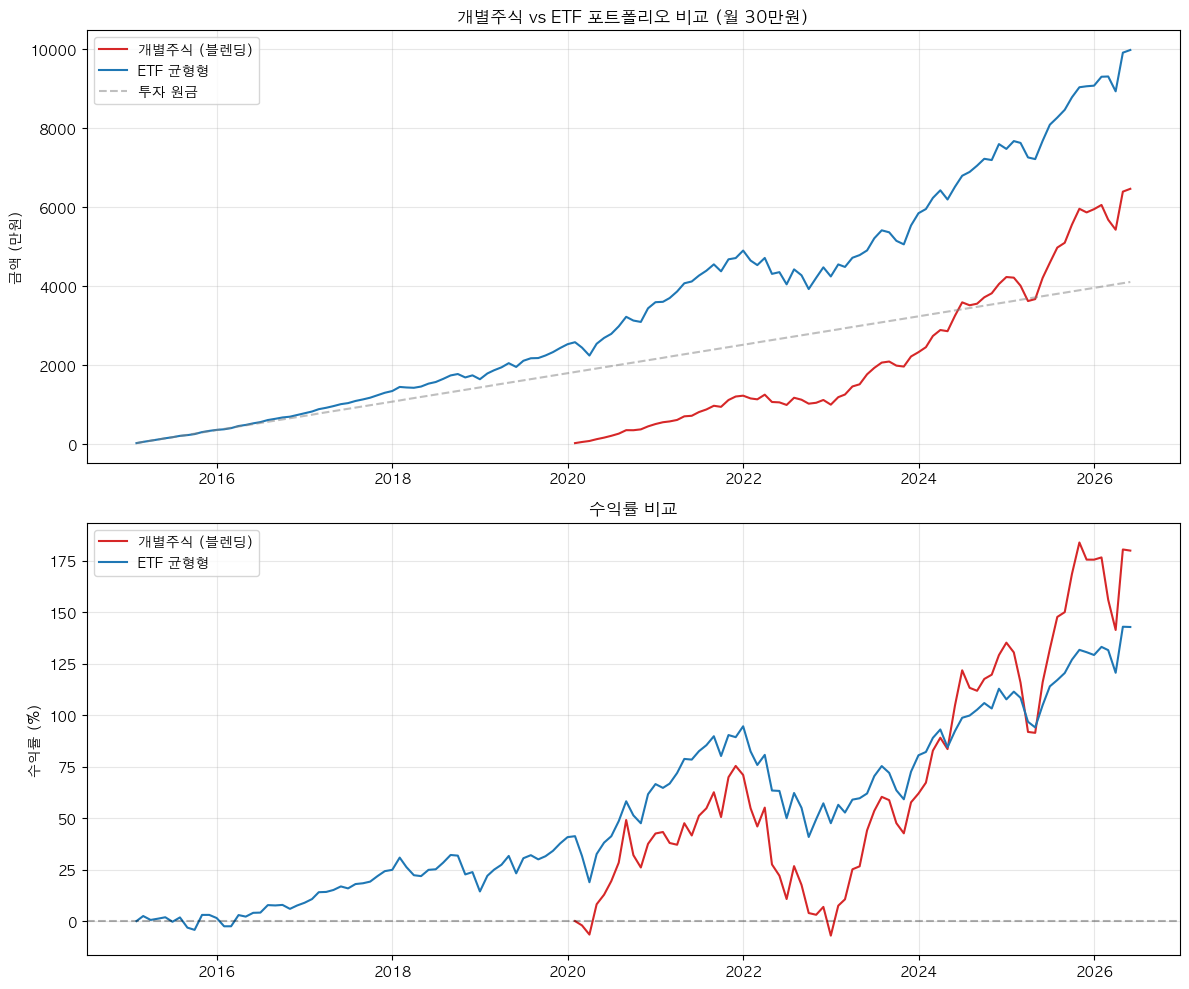

In [31]:
# 블렌딩 포트폴리오 백테스팅
weight_dict = dict(zip(stocks, blend_weights))
stock_result = backtest_monthly(stock_prices, weight_dict, monthly_amount=300000)

# ETF 균형형이랑 비교
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 상단: 자산 비교
axes[0].plot(stock_result.index, stock_result['포트폴리오 가치']/10000, 
             label='개별주식 (블렌딩)', color='#d62728')
axes[0].plot(r.index, r['포트폴리오 가치']/10000, 
             label='ETF 균형형', color='#1f77b4')
axes[0].plot(r.index, r['투자 원금']/10000, 
             '--', color='gray', label='투자 원금', alpha=0.5)
axes[0].set_title('개별주식 vs ETF 포트폴리오 비교 (월 30만원)')
axes[0].set_ylabel('금액 (만원)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 하단: 수익률 비교
stock_profit = (stock_result['포트폴리오 가치'] / stock_result['투자 원금'] - 1) * 100
etf_profit = (r['포트폴리오 가치'] / r['투자 원금'] - 1) * 100

axes[1].plot(stock_result.index, stock_profit, label='개별주식 (블렌딩)', color='#d62728')
axes[1].plot(r.index, etf_profit, label='ETF 균형형', color='#1f77b4')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_title('수익률 비교')
axes[1].set_ylabel('수익률 (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# 개별주식 결과 계산
stock_final = stock_result['포트폴리오 가치'].iloc[-1]
stock_invested = stock_result['투자 원금'].iloc[-1]
stock_profit = stock_final - stock_invested
stock_tax = max(0, stock_profit - 2_500_000) * 0.22
stock_after_tax = stock_final - stock_tax

# ETF 결과
etf_final = r['포트폴리오 가치'].iloc[-1]
etf_invested = r['투자 원금'].iloc[-1]
etf_profit = etf_final - etf_invested
etf_tax = max(0, etf_profit - 2_500_000) * 0.22
etf_after_tax = etf_final - etf_tax

# 블렌딩 비중 문자열
weight_str = ', '.join([f"{t} {w*100:.1f}%" for t, w in zip(stocks, blend_weights)])

prompt = f"""
당신은 한국인 투자자를 위한 전문 금융 어드바이저입니다.
두 가지 투자 전략을 비교 분석한 리포트를 한국어로 작성해주세요.

[전략 A: ETF 균형형]
- 구성: SPY 45%, QQQ 25%, BND 15%, SCHD 15%
- 투자기간: 2015년~현재 (약 11년)
- 월 투자금: 30만원
- 총 원금: {etf_invested/10000:,.0f}만원
- 세전 최종 자산: {etf_final/10000:,.0f}만원
- 총 수익: {etf_profit/10000:,.0f}만원
- 세후 자산: {etf_after_tax/10000:,.0f}만원

[전략 B: 개별주식 블렌딩 (최소분산 + 리스크패리티)]
- 구성: {weight_str}
- 투자기간: 2020년~현재 (약 5년)
- 월 투자금: 30만원
- 총 원금: {stock_invested/10000:,.0f}만원
- 세전 최종 자산: {stock_final/10000:,.0f}만원
- 총 수익: {stock_profit/10000:,.0f}만원
- 세후 자산: {stock_after_tax/10000:,.0f}만원

아래 형식으로 상세하게 작성해주세요:

📊 두 전략 성과 비교
(수익률, 변동성, 투자기간 차이 고려한 공정한 비교)

💡 각 전략의 장단점
(ETF의 안정성 vs 개별주식의 고수익 가능성)

⚠️ 한국인 투자자가 특히 주의할 점
(환율, 세금, 미국 시장 접근성)

🎯 투자자 유형별 추천
(초보/중급/고급 투자자에게 각각 어떤 전략이 맞는지)

🏦 절세 전략
(ISA 계좌, 연금저축펀드 활용법)
"""

response = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[{"role": "user", "content": prompt}]
)

print(response.choices[0].message.content)

📊 두 전략 성과 비교

두 전략의 성과를 비교하기 위해서는 수익률, 변동성, 투자기간의 차이를 고려해야 합니다. 전략 A (ETF 균형형)는 약 11년간의 투자기간 동안 총 원금 4,110만원으로 세전 최종 자산 9,983만원을 기록하였습니다. 이는 약 143%의 수익률을 나타내며, 월 평균 수익률은 약 9.5%입니다.另一方面, 전략 B (개별주석 블렌딩)는 약 5년간의 투자기간 동안 총 원금 2,310만원으로 세전 최종 자산 6,468만원을 기록하였습니다. 이는 약 180%의 수익률을 나타내며, 월 평균 수익률은 약 14.5%입니다.

그러나, 전략 B는 약 6년 ngắn은 투자기간 동안 기록한 수익률이므로, 장기적인 투자 성과를 평가하기 위해서는 더욱 긴 투자기간이 필요합니다. 또한, 전략 B는 개별주식으로 구성되어 변동성이 더 높은 편이므로, 투자자의 위험 감수 能力이 중요합니다.

💡 각 전략의 장단점

전략 A (ETF 균형형)의 장점은 안정성이 있습니다. ETF는 다양한 자산을 포함하므로, 특정 자산의 성과가 나빠도 전체적인 성과에 큰 영향을 주지 않습니다. 또한, ETF는 저렴한 비용으로 거래 가능하므로, 투자자의 비용을 최소화할 수 있습니다. 그러나, 전략 A의 단점은 수익률이 높지 않을 수 있습니다. ETF는 다양한 자산을 포함하므로, 전체적인 성과가 平均화될 수 있습니다.

전략 B (개별주식 블렌딩)의 장점은 고수익 가능성이 있습니다. 개별주식은 특정 산업이나 기업의 성과에 따라 급등할 수 있습니다. 그러나, 전략 B의 단점은 위험이 있습니다. 개별주식은 특정 산업이나 기업의 성과에 따라 급락할 수 있습니다. 따라서, 투자자의 위험 감수 能力이 중요합니다.

⚠️ 한국인 투자자가 특히 주의할 점

한국인 투자자는 특히 환율, 세금, 미국 시장 접근성을 주의해야 합니다. 환율은 외환 거래의 위험을 증가시킬 수 있습니다. 세금은 투자者的 수익을 감소시킬 수 있습니다. 또한, 미국 시장의 접근성은 투자者の 편의성을 증가시킬 수 있습니다.

🎯 